<a href="https://colab.research.google.com/github/shadmanr1/Milestone_2/blob/main/Week_8_Notebook_Shadman_Raakin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, KFold

#Dataset: Movie Box office (2000-2024)
General overview of the dataset is that it provides a detailed analysis of global box office performance from 2000 to 2024. It includes information on movies released during this period, covering key metrics such as release dates, genres, production budgets, worldwide gross, and more. The dataset aims to assist researchers, data scientists, and movie enthusiasts in exploring trends in the film industry, analyzing profitability, and understanding audience preferences over the years. https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?select=enhanced_box_office_data%282000-2024%29u.csv

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving enhanced_box_office_data(2000-2024)u.csv to enhanced_box_office_data(2000-2024)u.csv


In [ ]:
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")

In [ ]:
df["Rating_num"] = pd.to_numeric(df["Rating"].astype(str).str.extract(r"([0-9.]+)")[0],errors="coerce")

Selecting the predictors

In [ ]:
features = ["Year","Genres","Rating_num", "Vote_Count", "Original_Language", "Production_Countries"]
target = "Log_Worldwide"
numeric_features = [ "Year", "Rating_num", "Vote_Count"]
categorical_features = ["Genres","Original_Language","Production_Countries"]

Train and test split

In [ ]:
df["Log_Worldwide"] = np.log1p(df["$Worldwide"])

In [ ]:
train = df[df["Year"] <= 2019].copy()
test = df[df["Year"] >= 2020].copy()
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test_log = test[target]
y_test = test["$Worldwide"]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 4000
Testing observations: 1000


Data preprocess

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=5
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

KNN pipeline

In [ ]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsRegressor())
])

Tune KNN Pipeline

In [ ]:
parameter_grid = {
    "knn__n_neighbors": [3, 5, 10, 15, 20, 30, 50],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best parameters:
{'knn__n_neighbors': 20, 'knn__p': 2, 'knn__weights': 'distance'}


Evaluation

In [ ]:
best_knn = grid_search.best_estimator_
log_predictions = best_knn.predict(X_test)
predictions = np.expm1(log_predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.3f}")

MAE:  $76,267,140
RMSE: $169,942,379
R²:   0.277


Actuual vs Predicted revenue

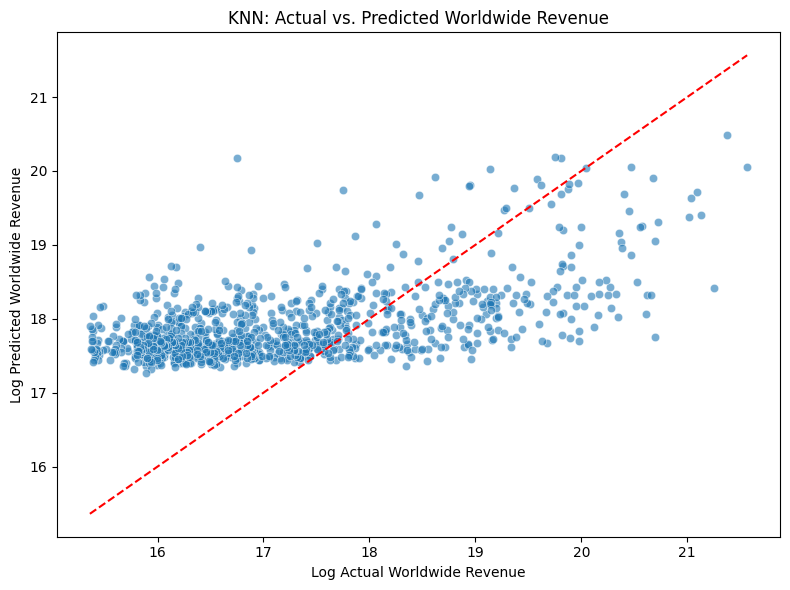

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=np.log1p(y_test),
    y=np.log1p(predictions),
    alpha=0.6)

minimum = min(
    np.log1p(y_test).min(),
    np.log1p(predictions).min())

maximum = max(
    np.log1p(y_test).max(),
    np.log1p(predictions).max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--")

plt.xlabel("Log Actual Worldwide Revenue")
plt.ylabel("Log Predicted Worldwide Revenue")
plt.title("KNN: Actual vs. Predicted Worldwide Revenue")
plt.tight_layout()
plt.show()

Examining Residuals

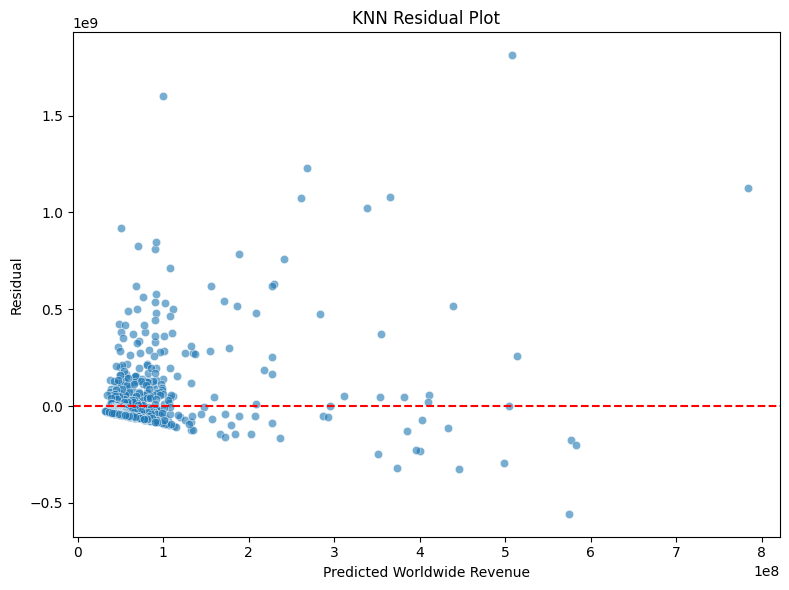

In [ ]:
residuals = y_test - predictions

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=predictions,
    y=residuals,
    alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--")

plt.xlabel("Predicted Worldwide Revenue")
plt.ylabel("Residual")
plt.title("KNN Residual Plot")
plt.tight_layout()
plt.show()

Positive residuals mean the movie earned more than predicted. Negative residuals mean it earned less than predicted. KNN underpredicts some of the largest blockbusters. This occurs because KNN averages the outcomes of neighboring movies and therefore has difficulty predicting revenues far outside the historical range of similar observations.

Presenting with each K value

In [ ]:
k_values = [3, 5, 10, 15, 20, 30, 50]

results = []

for k in k_values:
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("knn", KNeighborsRegressor(
            n_neighbors=k,
            weights="distance",
            p=2
        ))
    ])

    model.fit(X_train, y_train)

    pred = np.expm1(model.predict(X_test))

    results.append({
        "K": k,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

    K           MAE          RMSE        R2
0   3  8.077957e+07  1.710383e+08  0.267409
1   5  7.776473e+07  1.674036e+08  0.298214
2  10  7.725615e+07  1.696773e+08  0.279022
3  15  7.658732e+07  1.700102e+08  0.276190
4  20  7.626714e+07  1.699424e+08  0.276767
5  30  7.656497e+07  1.711645e+08  0.266327
6  50  7.776938e+07  1.740105e+08  0.241727


K-Nearest Neighbors regression was used to estimate worldwide box-office revenue by identifying movies with similar characteristics. The predictors included release year, genre, rating, vote count, original language, and production country. Numeric predictors were standardized because KNN calculates distances between observations, while categorical predictors were one-hot encoded. Worldwide revenue was log-transformed to reduce the influence of extremely successful blockbuster movies. Cross-validation selected a model using 15 neighbors, distance-based weighting, and Euclidean distance. On movies released from 2020 through 2024, the model achieved an R² of approximately 0.276, a mean absolute error of 76.6 million, and an RMSE of 170.0 million. These results show that movies with similar observed characteristics tend to have somewhat similar box-office outcomes, although a large portion of revenue variation remains unexplained